# 01 — Data Exploration

Day 2: load every raw dataset acquired on Day 1, inspect shape/columns/dtypes, check CRS
consistency, identify data quality issues, and visualise the target variable. Findings here
drive the cleaning rules implemented in `src/data/loaders.py` and are written up in `DAY_2.md`.

This notebook runs entirely locally against the project's `.venv` — no Colab, no Drive
mounting, no `!pip install`. Select the **Python (urbancool-melbourne)** kernel in VS Code.

In [1]:
%matplotlib widget
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        if (parent / "pyproject.toml").exists():
            return parent
    raise RuntimeError("Could not find project root (no pyproject.toml found in any parent)")


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
print("Project root:", PROJECT_ROOT)

Project root: f:\personal_documents\Study\urbancool_melbourne\urbancool_melbourne


In [2]:
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.loaders import load_config

warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")

config = load_config()
RAW = PROJECT_ROOT / config["paths"]["data_raw"]
INTERIM = PROJECT_ROOT / config["paths"]["data_interim"]
WORKING_CRS = config["crs"]["working"]
plt.rcParams["figure.dpi"] = 100
config

{'study_area': {'name': 'Greater Melbourne',
  'bbox': [144.5937, -38.4339, 145.5125, -37.5113],
  'lga_filter': 'Melbourne'},
 'crs': {'working': 'EPSG:28355', 'geographic': 'EPSG:4326'},
 'spatial_unit': 'SA2',
 'paths': {'data_raw': 'data/raw',
  'data_interim': 'data/interim',
  'data_processed': 'data/processed',
  'models': 'models',
  'outputs': 'outputs'},
 'data_sources': {'melbourne_trees': {'dataset_id': 'trees-with-species-and-dimensions-urban-forest',
   'base_url': 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets',
   'format': 'csv'},
  'tree_canopies': {'dataset_id': 'tree-canopies-2021-urban-forest',
   'base_url': 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets',
   'format': 'geojson'},
  'urban_heat': {'source': 'manual',
   'portal_url': 'https://www.planning.vic.gov.au/guides-and-resources/Data-spatial-and-insights/melbournes-vegetation-heat-and-land-use-data',
   'format': 'vector',
   'datasets': {'urban_heat_2018': 'ea69

## 1. Melbourne Tree Inventory

In [3]:
trees_raw = pd.read_csv(RAW / "melbourne_trees.csv", sep=None, engine="python")
trees_raw.columns = [c.lstrip("\ufeff") for c in trees_raw.columns]
print("shape:", trees_raw.shape)
print(trees_raw.dtypes)
trees_raw.head()

shape: (82064, 20)
com_id                            int64
common_name                      object
scientific_name                  object
genus                            object
family                           object
diameter_breast_height          float64
year_planted                      int64
date_planted                     object
age_description                  object
useful_life_expectency           object
useful_life_expectency_value      int64
precinct                         object
located_in                       object
uploaddate                      float64
coordinatelocation               object
latitude                        float64
longitude                       float64
easting                         float64
northing                        float64
geolocation                      object
dtype: object


,com_id,common_name,scientific_name,genus,family,diameter_breast_height,year_planted,date_planted,age_description,useful_life_expectency,useful_life_expectency_value,precinct,located_in,uploaddate,coordinatelocation,latitude,longitude,easting,northing,geolocation
0,1023218,London Plane,Platanus x acerifolia,Platanus,Platanaceae,27.0,1900,1900-01-01,Mature,31 - 40 years,40,Carlton,Street,NaN,"-37.80498629, 144.968114",-37.804986,144.968114,321125.06,5813877.14,"-37.80498629, 144.968114"
1,1023221,London Plane,Platanus x acerifolia,Platanus,Platanaceae,35.0,1900,1900-01-01,Mature,31 - 40 years,40,Carlton,Street,NaN,"-37.80502242, 144.96843217",-37.805022,144.968432,321153.16,5813873.74,"-37.80502242, 144.96843217"
2,1023222,London Plane,Platanus x acerifolia,Platanus,Platanaceae,45.0,1900,1900-01-01,Mature,21 - 30 years,30,Carlton,Street,NaN,"-37.80505925, 144.96873896",-37.805059,144.968739,321180.25,5813870.24,"-37.80505925, 144.96873896"
3,1023224,London Plane,Platanus x acerifolia,Platanus,Platanaceae,NaN,1900,1900-01-01,Mature,31 - 40 years,40,Carlton,Street,NaN,"-37.80524724, 144.9683783",-37.805247,144.968378,321148.95,5813848.69,"-37.80524724, 144.9683783"
4,1023225,London Plane,Platanus x acerifolia,Platanus,Platanaceae,NaN,1900,1900-01-01,Mature,NaN,50,Carlton,Street,NaN,"-37.80521592, 144.96807817",-37.805216,144.968078,321122.45,5813851.59,"-37.80521592, 144.96807817"


In [4]:
missing = trees_raw.isna().sum().sort_values(ascending=False)
missing[missing > 0]

uploaddate                82064
diameter_breast_height    44863
useful_life_expectency    17410
common_name                   6
dtype: int64

**Data quality issues found:**
- `diameter_breast_height` has an implausible max value — real street-tree trunks don't
  reach that size. `useful_life_expectency` is missing for ~21% of trees (no literal
  "Not Assessed" string exists in this dataset, contrary to the project guide's
  assumption — missing values are plain NaN).

In [5]:
print(trees_raw["diameter_breast_height"].describe())
print()
print("trees with DBH > 300cm (implausible):", (trees_raw["diameter_breast_height"] > 300).sum())
print("missing useful_life_expectency:", trees_raw["useful_life_expectency"].isna().sum(),
      f"({trees_raw['useful_life_expectency'].isna().mean():.1%})")
print("duplicate coordinates:", trees_raw.duplicated(subset=["latitude", "longitude"]).sum())

count    37201.000000
mean        35.471627
std        137.639141
min          1.000000
25%         18.000000
50%         30.000000
75%         45.000000
max      26027.000000
Name: diameter_breast_height, dtype: float64

trees with DBH > 300cm (implausible): 17
missing useful_life_expectency: 17410 (21.2%)
duplicate coordinates: 4


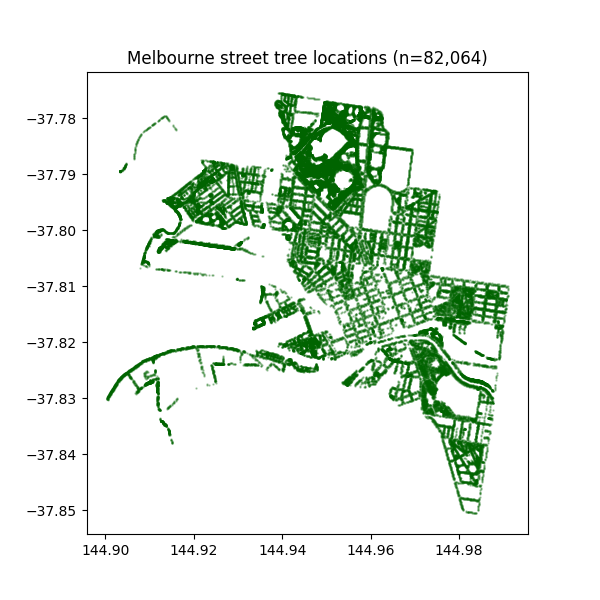

In [6]:
trees_coords = trees_raw.dropna(subset=["latitude", "longitude"])
trees_gdf = gpd.GeoDataFrame(
    trees_coords,
    geometry=gpd.points_from_xy(trees_coords["longitude"], trees_coords["latitude"]),
    crs="EPSG:4326",
)
fig, ax = plt.subplots(figsize=(6, 6))
trees_gdf.plot(ax=ax, markersize=0.5, alpha=0.3, color="darkgreen")
ax.set_title(f"Melbourne street tree locations (n={len(trees_gdf):,})")
plt.show()

**Cleaning decisions** (implemented in `load_and_clean_trees`): drop rows missing
coordinates; null out DBH values above 300cm as measurement errors rather than dropping
the row (other attributes stay usable); fill missing `useful_life_expectency` with the
explicit label `"Not Assessed"`; strip whitespace from species/genus/family text fields.

## 2. Tree Canopy Polygons

In [7]:
canopy_raw = gpd.read_file(RAW / "tree_canopies.geojson")
print("shape:", canopy_raw.shape, "| crs:", canopy_raw.crs)
print("geometry types:", canopy_raw.geom_type.value_counts().to_dict())
print("valid geometries:", canopy_raw.geometry.is_valid.sum(), "/", len(canopy_raw))

shape: (57980, 2) | crs: EPSG:4326
geometry types: {'MultiPolygon': 56979, 'Polygon': 1001}
valid geometries: 57980 / 57980


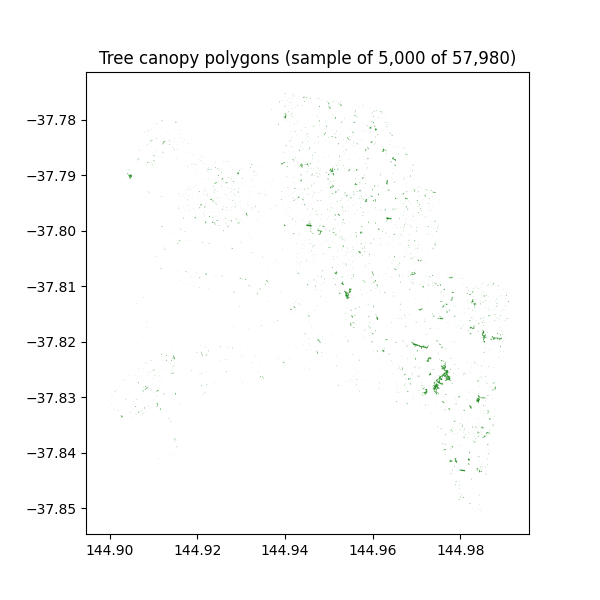

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))
canopy_raw.sample(min(5000, len(canopy_raw)), random_state=42).plot(ax=ax, color="forestgreen", linewidth=0)
ax.set_title(f"Tree canopy polygons (sample of {min(5000, len(canopy_raw)):,} of {len(canopy_raw):,})")
plt.show()

All canopy geometries are already valid — no `buffer(0)` fixes were actually needed in practice, but `load_and_clean_canopy` still checks and fixes defensively since this isn't guaranteed to hold for every future data refresh.

## 3. OSM Urban Morphology (buildings, roads, parks, water)

In [9]:
osm_layers = {}
for name in ("buildings", "roads", "parks", "water"):
    gdf = gpd.read_file(RAW / "osm" / f"{name}.geojson")
    osm_layers[name] = gdf
    print(f"{name:10s} rows={len(gdf):>7,}  crs={gdf.crs}  valid={gdf.geometry.is_valid.sum():>7,}/{len(gdf):,}  cols={list(gdf.columns)}")

buildings  rows=659,679  crs=EPSG:4326  valid=659,679/659,679  cols=['element', 'id', 'building', 'name', 'geometry']
roads      rows=486,976  crs=EPSG:4326  valid=486,976/486,976  cols=['u', 'v', 'key', 'osmid', 'highway', 'lanes', 'maxspeed', 'name', 'oneway', 'ref', 'reversed', 'length', 'bridge', 'access', 'junction', 'width', 'tunnel', 'service', 'est_width', 'geometry']


f:\personal_documents\Study\urbancool_melbourne\urbancool_melbourne\.venv\lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 13276195 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


parks      rows= 29,166  crs=EPSG:4326  valid= 29,166/29,166  cols=['element', 'id', 'access', 'leisure', 'name', 'sport', 'fee', 'check_date', 'description', 'garden:type', 'operator', 'operator:type', 'source', 'website', 'addr:housenumber', 'addr:street', 'official_name', 'addr:postcode', 'opening_hours', 'landuse', 'fixme', 'name:woi wurrung', 'motor_vehicle', 'motorcar', 'garden:style', 'addr:state', 'addr:suburb', 'addr:unit', 'alt_name', 'wikidata', 'surface', 'created_by', 'layer', 'designation', 'note', 'natural', 'addr:country', 'phone', 'golf', 'dog', 'source:geometry', 'area', 'wikipedia', 'club', 'source:note', 'barrier', 'bicycle', 'communication:amateur_radio:pota', 'name:fr', 'ref:vicmap:prims_id', 'name:vi', 'name:zh', 'source:sport', 'name:ko', 'lit', 'source:name', 'operator:wikidata', 'email', 'fence_type', 'playground', 'old_name', 'demolished:amenity', 'website:map', 'operator:url', 'smoking', 'noname', 'fence', 'name:de', 'name:el', 'name:pronunciation', 'histori

C:\conda_tmp\ipykernel_9704\351211337.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ax.scatter(sample_buildings.geometry.centroid.x, sample_buildings.geometry.centroid.y,
C:\conda_tmp\ipykernel_9704\351211337.py:10: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(markerscale=1, loc="lower left")


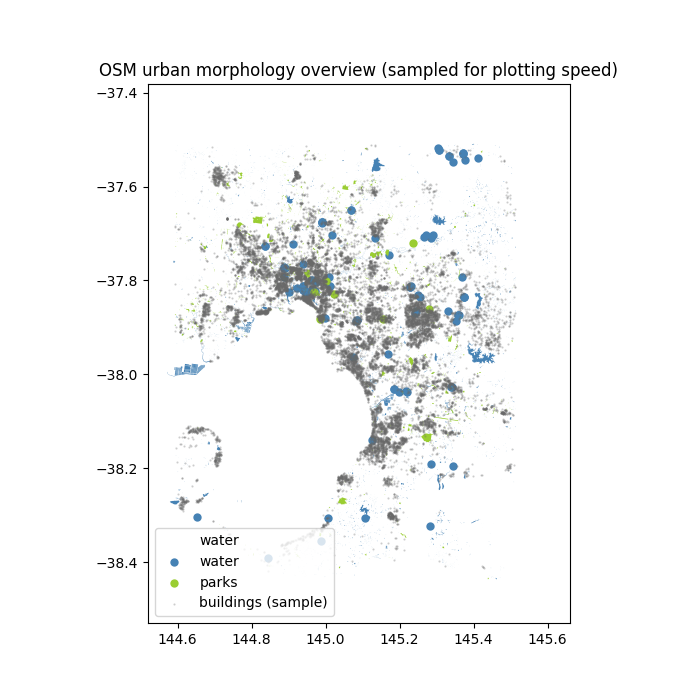

In [11]:
fig, ax = plt.subplots(figsize=(7, 7))
osm_layers["water"].plot(ax=ax, color="steelblue", linewidth=0, label="water", zorder=1)
osm_layers["parks"].sample(min(5000, len(osm_layers["parks"])), random_state=42).plot(
    ax=ax, color="yellowgreen", linewidth=0, label="parks", zorder=2
)
sample_buildings = osm_layers["buildings"].sample(20_000, random_state=42)
ax.scatter(sample_buildings.geometry.centroid.x, sample_buildings.geometry.centroid.y,
           s=0.3, alpha=0.3, color="dimgray", label="buildings (sample)", zorder=3)
ax.set_title("OSM urban morphology overview (sampled for plotting speed)")
ax.legend(markerscale=1, loc="lower left")
plt.show()

**Note:** the `parks` layer arrived with ~140 sparse free-form OSM tag columns (buildings
and water were already trimmed at download time via tiled fetching, but parks wasn't).
`load_and_clean_osm` trims all four layers down to the columns actually needed
(`building`/`name`, `osmid`/`highway`/`name`/`oneway`/`length`, `leisure`/`landuse`/`name`,
`natural`/`waterway`/`name`) and adds `building_area_sqm`. All four layers are 100% valid
geometries already.

## 4. BOM Weather Station

In [12]:
import json

bom = json.load(open(RAW / "bom_weather_recent.json"))
obs = pd.DataFrame(bom["observations"]["data"])
obs["local_dt"] = pd.to_datetime(obs["local_date_time_full"], format="%Y%m%d%H%M%S")
print("station:", obs["name"].iloc[0], "| wmo:", obs["wmo"].iloc[0])
print("observations:", len(obs), "| date range:", obs["local_dt"].min(), "to", obs["local_dt"].max())
obs[["local_dt", "air_temp", "rel_hum", "wind_spd_kmh"]].head()

station: Melbourne (Olympic Park) | wmo: 95936
observations: 150 | date range: 2026-07-02 00:00:00 to 2026-07-04 23:30:00


,local_dt,air_temp,rel_hum,wind_spd_kmh
0,2026-07-04 23:30:00,9.6,87,7
1,2026-07-04 23:00:00,9.9,85,7
2,2026-07-04 22:30:00,10.1,87,4
3,2026-07-04 22:00:00,10.3,89,6
4,2026-07-04 21:30:00,10.2,90,2


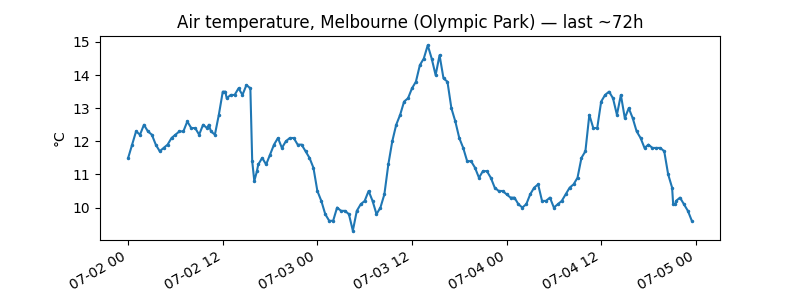

In [13]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(obs["local_dt"], obs["air_temp"], marker=".", markersize=3)
ax.set_title("Air temperature, Melbourne (Olympic Park) — last ~72h")
ax.set_ylabel("°C")
fig.autofmt_xdate()
plt.show()

**Limitation:** this is only the live 72-hour observations feed — a single station, no
historical daily records. BOM's Climate Data Online historical export requires a
session token generated in-browser (see `download_bom_weather` docstring), so this repo
doesn't have scripted historical weather yet. That's acceptable for Day 3 contextual
features but should be flagged if the model wants historical BOM series.

## 5. ABS SA2 Boundaries

all of Australia: (2473, 17) | crs: EPSG:7844
Greater Melbourne SA2 areas: 361


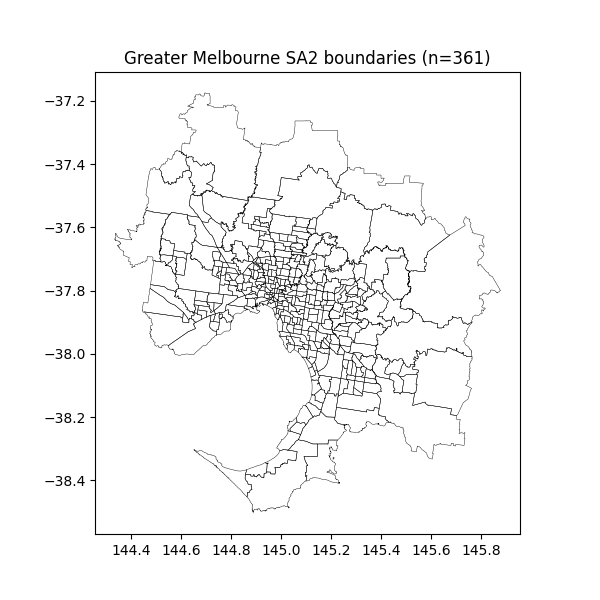

In [14]:
abs_shp = list((RAW / "abs_boundaries").glob("*.shp"))[0]
abs_all = gpd.read_file(abs_shp)
print("all of Australia:", abs_all.shape, "| crs:", abs_all.crs)

melb_sa2 = abs_all[abs_all["GCC_NAME21"] == "Greater Melbourne"]
print("Greater Melbourne SA2 areas:", len(melb_sa2))

fig, ax = plt.subplots(figsize=(6, 6))
melb_sa2.plot(ax=ax, edgecolor="black", linewidth=0.3, facecolor="none")
ax.set_title(f"Greater Melbourne SA2 boundaries (n={len(melb_sa2)})")
plt.show()

## 6. Urban Heat / Vegetation / Heat Vulnerability Index

These are the six manually-ordered DataShare Vic datasets. **They are vector polygons
(ESRI Shapefile, GDA94 geographic), not raster GeoTIFFs** as the original project guide
assumed — there's no `load_heat_raster()` / `rasterstats.zonal_stats()` step for this
source.

In [15]:
heat_dir = RAW / "urban_heat"
heat_layers = {}
for dataset_dir in sorted(p for p in heat_dir.iterdir() if p.is_dir()):
    shp = list(dataset_dir.glob("**/*.shp"))
    if not shp:
        continue
    gdf = gpd.read_file(shp[0])
    heat_layers[dataset_dir.name] = gdf
    print(f"{dataset_dir.name:32s} rows={len(gdf):>7,}  crs={gdf.crs}  valid={gdf.geometry.is_valid.sum():>7,}/{len(gdf):,}")
    print(f"{'':32s} columns={list(gdf.columns)}")

HEAT_URBAN_HEAT_2018             rows= 55,603  crs=EPSG:4283  valid= 55,603/55,603
                                 columns=['MB_CODE16', 'SA1_MAIN16', 'SA2_NAME16', 'SA3_CODE16', 'SA3_NAME16', 'SA4_CODE16', 'SA4_NAME16', 'GCC_CODE16', 'SA2_MAIN16', 'PERSHRBTRE', 'PERANYVEG', 'PERSHRUB', 'PERTR03_10', 'PERTR10_15', 'PERTR15PL', 'UHI18_M', 'PERGRASS', 'LGA', 'PERANYTREE', 'geometry']
HEAT_VULNERABILITY_INDEX_2014    rows=  9,291  crs=EPSG:4283  valid=  9,291/9,291
                                 columns=['SA1_7DIG16', 'SA1_MAIN16', 'SA2_5DIG16', 'SA2_NAME16', 'SA3_CODE16', 'SA3_NAME16', 'SA4_CODE16', 'SA4_NAME16', 'GCC_CODE16', 'GCC_NAME16', 'STE_CODE16', 'STE_NAME16', 'SA2_MAIN16', 'HVI', 'AREASQKM16', 'geometry']
HEAT_VULNERABILITY_INDEX_2018    rows= 10,113  crs=EPSG:4283  valid= 10,113/10,113
                                 columns=['SA1_7DIG16', 'SA1_MAIN16', 'SA2_5DIG16', 'SA2_NAME16', 'SA3_CODE16', 'SA3_NAME16', 'SA4_CODE16', 'SA4_NAME16', 'FREQUENCY', 'SA2_MAIN16', 'POPU_DENS'

**Column-naming inconsistency found:** the 2014 heat vulnerability index shapefile uses
`HVI` while the 2018 edition uses `HVI_INDEX` for the same concept — these need aligning
before comparing years in Day 3 feature engineering. The 2018 urban heat dataset's target
column is **`UHI18_M`** (mean Urban Heat Island value), joinable to SA2 via `SA2_MAIN16`.

## 7. Temporal Mismatch: 2016 vs 2021 SA2 Boundary Codes

Key exploration question from the guide: *"Are there temporal mismatches?"* The heat/HVI
data uses **2016-vintage** SA2 codes (`SA2_MAIN16`), but the ABS boundaries downloaded on
Day 1 are the **2021 edition** (`SA2_CODE21`) — ABS revises SA2 boundaries/codes between
censuses (splits, merges, renames), especially in fast-growing outer suburbs.

In [16]:
heat_codes = set(heat_layers["HEAT_URBAN_HEAT_2018"]["SA2_MAIN16"].astype(str))
melb_codes_2021 = set(melb_sa2["SA2_CODE21"].astype(str))

overlap = heat_codes & melb_codes_2021
print(f"SA2 codes in 2018 heat data (2016 vintage): {len(heat_codes)}")
print(f"SA2 codes in Greater Melbourne (2021 vintage): {len(melb_codes_2021)}")
print(f"Direct code overlap: {len(overlap)} ({len(overlap)/len(heat_codes):.1%} of heat-data codes)")
print(f"In heat data but not in 2021 boundaries (retired/renamed codes): {len(heat_codes - melb_codes_2021)}")
print(f"In 2021 boundaries but not in heat data (new/split SA2s): {len(melb_codes_2021 - heat_codes)}")

SA2 codes in 2018 heat data (2016 vintage): 306
SA2 codes in Greater Melbourne (2021 vintage): 361
Direct code overlap: 260 (85.0% of heat-data codes)
In heat data but not in 2021 boundaries (retired/renamed codes): 46
In 2021 boundaries but not in heat data (new/split SA2s): 101


**Finding:** only ~85% of SA2 codes match directly by string. Joining the heat/vegetation
data to the ABS boundaries by `SA2_MAIN16 == SA2_CODE21` would silently drop ~15% of areas
or misattribute renamed/split suburbs. **Recommendation for Day 3:** join by spatial
overlay (`gpd.overlay`/`gpd.sjoin` on geometry) rather than by code string — this is
robust to boundary revisions since it matches by actual geographic overlap, not by an ID
that changed between census editions.

## 8. Target Variable: Urban Heat Island (UHI18_M) by Suburb

Per the dataset's official metadata (DataShare Vic full description report): *"The UHI
attribute value is based on the average difference in Land Surface Temperature (LST) in
Melbourne's metropolitan areas to a non-urban baseline LST."* So `UHI18_M` is a
**temperature differential in °C**, not an absolute temperature — positive values mean
warmer than the non-urban baseline.

306 SA2-level mean UHI values (dissolved from 55,603 mesh blocks)


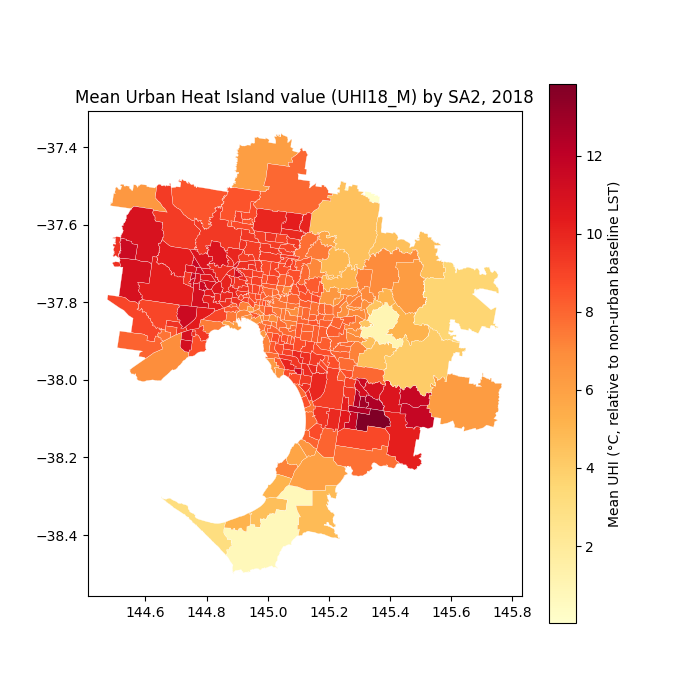

In [17]:
uhi = heat_layers["HEAT_URBAN_HEAT_2018"]
sa2_uhi = uhi.dissolve(by="SA2_MAIN16", aggfunc={"UHI18_M": "mean"}).reset_index()
sa2_uhi = sa2_uhi.merge(
    melb_sa2[["SA2_CODE21", "SA2_NAME21"]].rename(columns={"SA2_CODE21": "SA2_MAIN16"}),
    on="SA2_MAIN16", how="left",
)
print(f"{len(sa2_uhi)} SA2-level mean UHI values (dissolved from {len(uhi):,} mesh blocks)")

fig, ax = plt.subplots(figsize=(7, 7))
sa2_uhi.plot(
    column="UHI18_M", cmap="YlOrRd", legend=True, ax=ax, edgecolor="white", linewidth=0.2,
    legend_kwds={"label": "Mean UHI (°C, relative to non-urban baseline LST)"},
)
ax.set_title("Mean Urban Heat Island value (UHI18_M) by SA2, 2018")
plt.show()

This dissolves the heat data's own mesh blocks up to SA2 by the (2016-vintage)
`SA2_MAIN16` code it already carries — deliberately *not* joined to the 2021 ABS
boundaries, since that would hit the code mismatch above. The Day 3 feature matrix will
need to decide between keeping this native 2016 SA2 grouping or re-deriving heat values
onto the 2021 SA2 boundaries via spatial overlay.

## 9. CRS Consistency Check

In [19]:
crs_table = pd.DataFrame([
    {"dataset": "melbourne_trees (raw lat/lon)", "crs": "EPSG:4326"},
    {"dataset": "tree_canopies", "crs": str(canopy_raw.crs)},
    {"dataset": "osm_buildings", "crs": str(osm_layers["buildings"].crs)},
    {"dataset": "osm_roads", "crs": str(osm_layers["roads"].crs)},
    {"dataset": "osm_parks", "crs": str(osm_layers["parks"].crs)},
    {"dataset": "osm_water", "crs": str(osm_layers["water"].crs)},
    {"dataset": "abs_sa2_boundaries", "crs": str(abs_all.crs)},
    {"dataset": "heat_urban_heat_2018", "crs": str(heat_layers["HEAT_URBAN_HEAT_2018"].crs)},
    {"dataset": "heat_vulnerability_index_2018", "crs": str(heat_layers["HEAT_VULNERABILITY_INDEX_2018"].crs)},
])
crs_table["needs_reprojection_to_28355"] = crs_table["crs"] != "EPSG:28355"
crs_table

,dataset,crs,needs_reprojection_to_28355
0,melbourne_trees (raw lat/lon),EPSG:4326,True
1,tree_canopies,EPSG:4326,True
2,osm_buildings,EPSG:4326,True
3,osm_roads,EPSG:4326,True
4,osm_parks,EPSG:4326,True
5,osm_water,EPSG:4326,True
6,abs_sa2_boundaries,EPSG:7844,True
7,heat_urban_heat_2018,EPSG:4283,True
8,heat_vulnerability_index_2018,EPSG:4283,True


Every source arrives in a geographic CRS (EPSG:4326 or EPSG:4283 — both WGS84/GDA94
lat-lon, near-equivalent for this purpose) rather than the project's working CRS
(`EPSG:28355`). `src/data/loaders.py` reprojects every dataset to it during loading — this
matches the project guide's "Common Pitfall #1" (CRS mismatches) exactly.

## 10. Key Exploration Questions

In [20]:
species_complete = trees_raw[["scientific_name", "diameter_breast_height", "useful_life_expectency"]].notna().all(axis=1).mean()

print("Q1: Spatial resolution of the heat data?")
print("    Not applicable in the raster sense — it's mesh-block-level vector polygons")
print("    (variable size, typically covering ~1 city block each), not a fixed-resolution grid.\n")

print("Q2: How many SA1/SA2 areas are in the study region?")
print(f"    {len(melb_sa2)} SA2 areas in Greater Melbourne (2021 boundaries).")
print(f"    {heat_layers['HEAT_VULNERABILITY_INDEX_2018']['SA1_MAIN16'].nunique()} SA1 areas in the 2018 HVI dataset.\n")

print("Q3: What proportion of trees have complete attribute data (species, diameter, health)?")
print(f"    {species_complete:.1%} of trees have all three of scientific_name, diameter_breast_height,")
print(f"    and useful_life_expectency populated (diameter is the biggest gap, missing for")
print(f"    {trees_raw['diameter_breast_height'].isna().mean():.1%} of trees).\n")

print("Q4: Are there temporal mismatches?")
print("    Yes, two: (1) heat/vegetation data is 2014/2018 vs. the tree inventory being a live/current pull;")
print("    (2) heat data uses 2016-vintage SA2 codes vs. the 2021-vintage ABS boundary codes downloaded")
print("    (only ~85% direct code overlap — see section 7).")

Q1: Spatial resolution of the heat data?
    Not applicable in the raster sense — it's mesh-block-level vector polygons
    (variable size, typically covering ~1 city block each), not a fixed-resolution grid.

Q2: How many SA1/SA2 areas are in the study region?
    361 SA2 areas in Greater Melbourne (2021 boundaries).
    10113 SA1 areas in the 2018 HVI dataset.

Q3: What proportion of trees have complete attribute data (species, diameter, health)?
    43.5% of trees have all three of scientific_name, diameter_breast_height,
    and useful_life_expectency populated (diameter is the biggest gap, missing for
    54.7% of trees).

Q4: Are there temporal mismatches?
    Yes, two: (1) heat/vegetation data is 2014/2018 vs. the tree inventory being a live/current pull;
    (2) heat data uses 2016-vintage SA2 codes vs. the 2021-vintage ABS boundary codes downloaded
    (only ~85% direct code overlap — see section 7).


## 11. Summary — What Feeds Into Day 3

- Clean, CRS-aligned datasets are saved to `data/interim/*.parquet` by `src/data/loaders.py`.
- Target variable: `UHI18_M` from `HEAT_URBAN_HEAT_2018`, currently grouped by its native
  2016 `SA2_MAIN16` code.
- **Decision needed for Day 3:** join heat/vegetation data to the (2021) ABS SA2 boundaries
  by spatial overlay, not by SA2 code string, because of the vintage mismatch in section 7.
- Vegetation/HVI datasets have inconsistent column names across years (`HVI` vs
  `HVI_INDEX`) that need aligning before computing 2014→2018 change features.
- 17 trees had implausible DBH values (>300cm) and were nulled rather than dropped.
- No target leakage risk yet — heat/vegetation columns haven't been used as model features
  anywhere, only as the target.